In [32]:
# import Pkg
using JuMP
using Printf
using Convex
using Gurobi
using LinearAlgebra
using Random
using SparseArrays
using Plots
using Ipopt
using JLD

include("proximal_bundle_method_main/src/solver.jl")
include("proximal_bundle_method_main/src/data_cleaning.jl")
include("proximal_bundle_method_main/src/PBA_utils.jl")

solve_PBA (generic function with 3 methods)

In [2]:
function compute_minimum_with_cvx(Xp, y, reg_coeff)
    n, m = size(Xp)
    w = Convex.Variable(m)
    problem = Convex.minimize(
        (reg_coeff / 2) * Convex.sumsquares(w) +
        Convex.sum(Convex.pos((1 - y .* (Xp * w)) / n)),
    )
    
    Convex.solve!(
        problem,
        () -> Gurobi.Optimizer(),
        # () -> Gurobi.Optimizer(BarConvTol = 1e-10, BarQCPConvTol = 1e-10),
        # () -> SCS.Optimizer(verbose=false), 
        # verbose=false
    ) #
    return problem
end

# problem = compute_minimum_with_cvx(Xp, y, coeff);


compute_minimum_with_cvx (generic function with 1 method)

# Load and normalize data

In [3]:
@enum Manage_bundle Keep_all Keep_active Keep_active_null_step
color_dic = Dict(Keep_all=>"green", Keep_active=>"red", Keep_active_null_step=>"blue");
dic_names_method = Dict(Keep_all=>"All-cut", Keep_active=>"Active-cut", Keep_active_null_step=>"Single-cut");


function make_master_model(n, rho, x_center)
    master_model =  Model(Ipopt.Optimizer)
    set_optimizer_attribute(master_model, "print_level", 0)
    set_optimizer_attribute(master_model, "tol", 1e-8)
    
    @variable(master_model, x[1:n])
    @variable(master_model, z)
#     @NLobjective(master_model, Min,log(exp(sum(x[i]^2 for i in 1:n))+1) + z + rho*sum((x[i]-x_center[i])^2 for i in 1:n));
    @NLobjective(master_model, Min,coeff/2*sum(x[i]^2 for i in 1:n) + z + rho/2*sum((x[i]-x_center[i])^2 for i in 1:n));
    
    return master_model
end

function make_cut(x_value, i_model)
    @objective(i_model, Max, sum(i_model.obj_dict[:y][1:end-1] .* x_value) + i_model.obj_dict[:y][end]);
    optimize!(i_model)
    obj_value = objective_value(i_model)
    y_opt = value.(i_model.obj_dict[:y])
    return obj_value, y_opt
end

function add_cut(x_value, m_model, dict_cut, iter)
    obj_value = objective(x_value)
    y_opt = gradient(x_value)
    dict_cut[iter] = @constraint(m_model, m_model.obj_dict[:z]>= sum(y_opt.*(m_model.obj_dict[:x] .- x_value)) + obj_value);
    return obj_value
end

function update_proximal_center(m_model, x_center, rho)
    n = length(m_model.obj_dict[:x])
    
    @NLobjective(m_model, Min, coeff/2*sum(m_model.obj_dict[:x][i]^2 for i in 1:n) + m_model.obj_dict[:z] + rho/2*sum((m_model.obj_dict[:x][i]-x_center[i])^2 for i in 1:n));

#     @NLobjective(m_model, Min, log(exp(sum(m_model.obj_dict[:x][i] for i in 1:n))+1) + m_model.obj_dict[:z] + rho*sum((m_model.obj_dict[:x][i]-x_center[i])^2 for i in 1:n));
end

function keep_active_cuts(dict_cut, m_model, verbose)
    dual_dict_cut = Dict(key => dual(value) for (key, value) in dict_cut)
    d = length(m_model.obj_dict[:x])
    n_cuts = length(dual_dict_cut)
    min_dual = 1e-5
    if n_cuts>d+1
        l = reverse(sort([dual(value) for (key, value) in dict_cut]))[d+2]
        min_dual = max(min_dual, l)
    end
    for k in (keys(dual_dict_cut))
        if (dual_dict_cut[k])<min_dual
            if verbose
                println("Cut ",k," deleted")
            end
            delete(m_model, dict_cut[k])
            pop!(dict_cut, k)
        end
    end
end
function keep_all_cuts(dict_cut, master_model, verbose)
end

function clear_all_cut_but(dict_cut, master_model, lst_to_keep, verbose)
    for k in keys(dict_cut)
        if !(k in lst_to_keep)
            if verbose
                println("Cut ",k," deleted")
            end
            delete(master_model, dict_cut[k])
            pop!(dict_cut, k)
        end
    end
end


clear_all_cut_but (generic function with 1 method)

In [4]:
"""
The following functions are used to process LIBSVM files.
"""
mutable struct LearningData
    feature_matrix
    labels::Vector{Float64}
end

function load_libsvm_file(file_name::String)
    open(file_name, "r") do io
        target = Array{Float64,1}()
        row_indicies = Array{Int64,1}()
        col_indicies = Array{Int64,1}()
        matrix_values = Array{Float64,1}()
        row_index = 0
        for line in eachline(io)
            row_index += 1
            split_line = split(line)
            label = parse(Float64, split_line[1])
            # This ensures that labels are 1 or -1. Different dataset use {-1, 1}, {0, 1}, and {1, 2}.
            if abs(label - 1.0) < 1e-05
                label = 1.0
            else
                label = -1.0
            end
            push!(target, label)
            for i = 2:length(split_line)
                push!(row_indicies, row_index)
                matrix_coef = split(split_line[i], ":")
                push!(col_indicies, parse(Int64, matrix_coef[1]))
                push!(matrix_values, parse(Float64, matrix_coef[2]))
            end
        end
        feature_matrix = sparse(row_indicies, col_indicies, matrix_values)
        return LearningData(feature_matrix, target)
    end
end

function normalize_columns(feature_matrix::SparseMatrixCSC{Float64,Int64})
    m = size(feature_matrix, 2)
    normalize_columns_by = ones(m)
    for j = 1:m
        col_vals = feature_matrix[:, j].nzval
        if length(col_vals) > 0
            normalize_columns_by[j] = 1.0 / norm(col_vals, 2)
        end
    end
    return feature_matrix * sparse(1:m, 1:m, normalize_columns_by)
end

function remove_empty_columns(feature_matrix::SparseMatrixCSC{Float64,Int64})
    keep_cols = Array{Int64,1}()
    for j = 1:size(feature_matrix, 2)
        if length(feature_matrix[:, j].nzind) > 0
            push!(keep_cols, j)
        end
    end
    return feature_matrix[:, keep_cols]
end

function add_intercept(feature_matrix::SparseMatrixCSC{Float64,Int64})
    return [sparse(ones(size(feature_matrix, 1))) feature_matrix]
end


function preprocess_learning_data(result::LearningData)
    result.feature_matrix = remove_empty_columns(result.feature_matrix)
    result.feature_matrix = add_intercept(result.feature_matrix)
    result.feature_matrix = normalize_columns(result.feature_matrix)
    result.feature_matrix = Matrix(result.feature_matrix)
    return result
end

preprocess_learning_data (generic function with 1 method)

In [5]:
function compute_minimum_with_jump(Xp::Matrix{Float64}, y::Vector{Float64}, reg_coeff::Float64, accuracy = 1e-10)
    n, m = size(Xp)
    model = Model(Gurobi.Optimizer)
    set_optimizer_attribute(model, "BarConvTol", accuracy)
    set_optimizer_attribute(model, "BarQCPConvTol", accuracy)
    # Define the optimization variable
    @variable(model, w[1:m])
    # Define a variable to represent the hinge loss
    @variable(model, ξ[1:n] >= 0)
    # Define the objective function
    @objective(model, Min,
        (reg_coeff / 2) *sum(w[i]^2 for i in 1:m) +
         (1/n)*sum(ξ[i] for i in 1:n)
    )
    # Define constraints to represent the hinge loss
    for i in 1:n
        @constraint(model, ξ[i] >= 1 - y[i] * dot(Xp[i, :],w))
    end
    # Solve the problem
    optimize!(model)
    # Extract and return the solution
    w_opt = value.(w)
    return objective_value(model)
end

compute_minimum_with_jump (generic function with 2 methods)

In [6]:
function svm_objective(w, Xp, y, coeff, full_function)
    n, _ = size(Xp)
    soft_margin = map(x -> max(0, x), ones(length(y)) - y .* (Xp * w))
    if full_function
        return sum(soft_margin) / n + coeff / 2 * LinearAlgebra.norm(w)^2
    end
    return sum(soft_margin) / n
end

function svm_subgradient(w, Xp, y, coeff, full_function)
    n, m = size(Xp)
    soft_margin = map(x -> max(0, x), ones(length(y)) - y .* (Xp * w))
    result = zeros(length(w))
    for i = 1:length(soft_margin)
        if soft_margin[i] > 0.0
            result += -y[i] * Xp[i, :] / n
        end
    end
    if full_function
        return result + coeff * w
    end
    return result
end

function get_sliding_min(arr)
    best_val_so_far = Inf
    arr_best_val_so_far = ones(length(arr)).+Inf
    for i in 1:length(arr)
        arr_best_val_so_far[i] = min(best_val_so_far,arr[i])
        best_val_so_far = arr_best_val_so_far[i]
    end 
    return arr_best_val_so_far
end

get_sliding_min (generic function with 1 method)

# Compute global optima and utils

In [7]:
Random.seed!(2625)
# instance_names = ["colon-cancer", "duke", "leu", "ijcnn1", "skin_nonskin", "gisette_scale", "covtype"]
name = "covtype"
instance_names = [name]
# coefficients = [0.001, 0.01, 0.1, 0.5, 1.0, 1.5, 2.0, 10.0]
# step_sizes = [1e-15 * 100^j for j = 0:10]

instances = Dict()
for name in instance_names
    instances[name] = preprocess_learning_data(load_libsvm_file("proximal_bundle_method_main/data/" * name))
    samples, features  = size(instances[name].feature_matrix)
    println(name* " --- number of features = "*string(features)*" || number of samples = "*string(samples))
end

covtype --- number of features = 55 || number of samples = 581012


In [8]:
# for (name, instance) in instances
#     Xp = (instance.feature_matrix)
#     y = instance.labels
#     _, m = size(Xp)
#     x_init = randn(m) / m
#     for coeff in coefficients
#         print("\n------------------------------------\n")
#         Printf.@printf("Instance %s, coeff %12g\n", name, coeff)
#         println("Solving with Convex.jl first")
#         problem = compute_minimum_with_cvx(Xp, y, coeff)
#         Printf.@printf("Obj=%12g\n", problem.optval,)
#     end
# end

In [9]:
max_nb_samples = 200000#Inf
# name = "covtype"
# name = "covtype" #this works well
instance = instances[name]
Xp = (instance.feature_matrix)
y = instance.labels
try
    # Determine the number of samples to draw
    nb_samples = min(max_nb_samples, size(Xp, 1))
    
    # Generate a random permutation of indices
    indices = randperm(size(Xp, 1))[1:nb_samples]
    
    # Select the samples using the random indices
    Xp = Xp[indices, :]
    y = y[indices]
catch
    # Handle any potential errors
end

n, m = size(Xp)

x_init = randn(m) / m
coefficients = [0.01/n]
coeff = coefficients[1]
print("\n------------------------------------\n")
Printf.@printf("Instance %s, coeff %12g\n", name, coeff)
println("Solving with Convex.jl first")
opt_val = compute_minimum_with_jump(Xp, y, coeff)
Printf.@printf("Obj=%12g\n", opt_val,)


------------------------------------
Instance covtype, coeff        5e-08
Solving with Convex.jl first
Set parameter TokenServer to value "flexlm"
Set parameter BarConvTol to value 1e-10
Set parameter BarQCPConvTol to value 1e-10
Set parameter BarQCPConvTol to value 1e-10
Set parameter BarConvTol to value 1e-10
Gurobi Optimizer version 10.0.0 build v10.0.0rc2 (linux64)

CPU model: Intel(R) Xeon(R) Platinum 8260 CPU @ 2.40GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 48 physical cores, 96 logical processors, using up to 32 threads

Optimize a model with 200000 rows, 200055 columns and 2775730 nonzeros
Model fingerprint: 0xb7e90fbb
Model has 55 quadratic objective terms
Coefficient statistics:
  Matrix range     [7e-06, 1e+00]
  Objective range  [5e-06, 5e-06]
  QObjective range [5e-08, 5e-08]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 0 rows and 1 columns
Presolve time: 0.56s
Presolved: 200000 rows, 200054 columns, 2775730 nonzeros


# Benchmarks

## Params

In [10]:
eps_optimal = 1e-5
timeout = 5
verbose =  false


iteration_limit = 2000
printing_frequency = 10
full_function = true
objective = (w -> svm_objective(w, Xp, y, coeff, full_function) - opt_val)
gradient = (w -> svm_subgradient(w, Xp, y, coeff,full_function))

#Pegasos
batch_size = Int(floor(size(Xp)[1]/10))
# batch_size = 5

20000

## Pegasos

In [11]:
struct Pegasos_Output
    list_iter_index_pegasos::Vector{Float64}
    list_obj_value_gap_pegasos::Vector{Float64}
    list_times_pegasos::Vector{Float64}
end


# Implementation from the SVM.jl package https://github.com/JuliaStats/SVM.jl/tree/master
#number of iterations will be floor(iteration_limit * size(Xp)[1]/batch_size)
function pegasos(Xp, Y, opt_val, k::Integer = 5, lambda::Real = 0.1, maxpasses::Integer = 100, printing_frequency = 50, eps_optimal = 1e-7,verbose = true, timeout = 3600)
    # p features, n observations
    
    X = transpose(Xp)
    coeff = lambda
    list_obj_value_gap = [svm_objective(x_init, Xp, y, coeff, true) - opt_val]
    list_times = [0.]
    list_iter_index = [0.]
    p, n = size(X)
    new_printing_freq =  Int(floor(printing_frequency*n/k))
    has_timeout_pegasos = false
    ti = time()
    
    # Initialize weights so norm(w) <= 1 / sqrt(lambda)
    w = x_init
    sqrtlambda = sqrt(lambda)
    normalizer = sqrtlambda * norm(w)
    for j in 1:p
        w[j] /= normalizer
    end

    # Allocate storage for repeated used arrays
    deltaw = zeros(p)
    w_tmp = zeros(p)

    # Loop
    for t in 1:maxpasses
        # Calculate stepsize parameters
        alpha = 1.0 / t
        eta_t = 1.0 / (lambda * t)
        # Calculate scaled sum over misclassified examples
        # Subgradient over minibatch of size k
        fill!(deltaw, 0.0)
        for i in 1:k
            # Select a random item from X
            # This is one element of At of S
            index = rand(1:n)
            # Test if prediction isn't sufficiently good
            # If so, current item is element of At+
            pred = Y[index] * dot(w, X[:, index])
            if pred < 1.0
                # Update subgradient
                for j in 1:p
                    deltaw[j] += Y[index] * X[j, index]
                end
            end
        end
        
        for j in 1:p
            deltaw[j] *= (eta_t / k)
        end

        # Calculate tentative weight-update
        for j in 1:p
            w_tmp[j] = (1.0 - alpha) * w[j] + deltaw[j]
        end
        # # Rescale subgradient
        # for j in 1:p
        #     deltaw.*= (eta_t / k)
        # end
        # # Calculate tentative weight-update
        # for j in 1:p
        #     w_tmp = (1.0 - alpha) .* w .+ deltaw
        # end
        # Find projection of weights into L2 ball
        proj = min(1.0, 1.0 / (sqrtlambda * norm(w_tmp)))
        for j in 1:p
            w[j] = proj * w_tmp[j]
        end
        w = w_tmp
        
        if t%new_printing_freq==0
            this_val = objective(w)
            push!(list_obj_value_gap, this_val)
            if verbose
                Printf.@printf("Gap=%12g\n", this_val)
                flush(stdout)
            end
            push!(list_times, time()-ti)
            push!(list_iter_index, t * batch_size / size(Xp)[1])
            if this_val<eps_optimal
                break
            end
            if time()-ti>timeout
                has_timeout_pegasos = true
                break
            end
        end
    end
    return (svm_objective(x_init, Xp, y, coeff, true), maxpasses, list_obj_value_gap, list_times, list_iter_index, w, has_timeout_pegasos)
end

pegasos (generic function with 8 methods)

In [12]:
(obj, maxpasses, list_obj_value_gap_pegasos, list_times_pegasos,list_iter_index_pegasos, w, has_timeout_pegasos) = pegasos(Xp, y,opt_val, batch_size, coeff, Int(floor(iteration_limit * size(Xp)[1]/batch_size)), printing_frequency, eps_optimal, verbose, timeout);

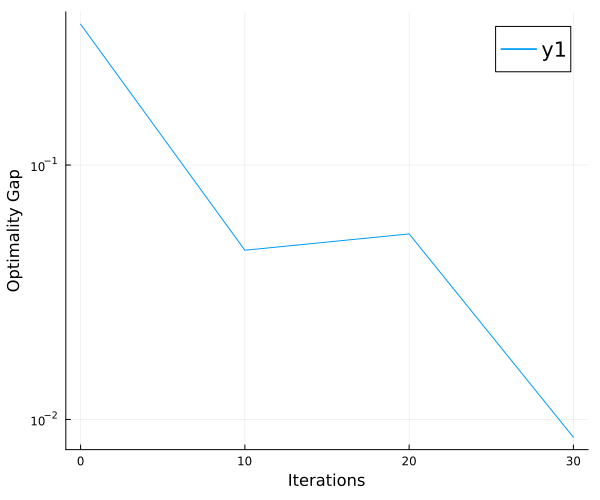

In [13]:
# plot(list_obj_value_gap)
p = plot(size = (600,500))

# plot!(list_iter_index, get_sliding_min(list_obj_value_gap))
plot!(list_iter_index_pegasos, (list_obj_value_gap_pegasos))
# for manage_bundle in manage_bundle_values
#     plot!(dic_gaps[manage_bundle], label = "", color = color_dic[manage_bundle],linewidth=4)
# end
# hline!([epsilon], linestyle=:dash, label="Tolerance", color = "grey")
xlabel!("Iterations")
ylabel!("Optimality Gap")
plot!(legendfontsize=14)
# y_ticks = range(1e-4, stop=1e1, length=20)
# title!("Progress for different bundle management strategies")
plot!(yaxis=:log, yticks = [1e-5, 1e-4, 1e-3, 1e-2,1e-1, 1])
# ylims!(1e-5, 100)
savefig(p, "Optimality_gap.pdf") 
plot!()

## Subgradient method

In [14]:
opt_val

0.6423203246548153

In [15]:
params_subgradient = SubgradientMethodParams(
        eps_optimal,
        iteration_limit,
        verbose,
        printing_frequency,
        timeout
    )
poly_step_size = ((_, _, t) -> 1 / (coeff * t))
sol_subgradient = solve(
                objective,
                gradient,
                params_subgradient,
                poly_step_size,
                x_init,);

In [16]:
w = sol_subgradient.solution;
objective(w)

1.2308737548143835

In [17]:
objective(sol_subgradient.solution)
svm_objective(sol_subgradient.solution, Xp, y, coeff, true)
sol_subgradient.iteration_stats;

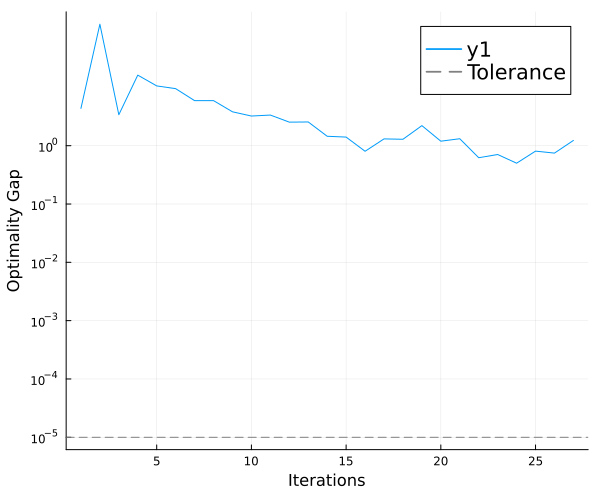

In [18]:
p = plot(size = (600,500))

# plot!(get_sliding_min([s.objective for s in sol_subgradient.iteration_stats]))
plot!([s.objective for s in sol_subgradient.iteration_stats])
# for manage_bundle in manage_bundle_values
#     plot!(dic_gaps[manage_bundle], label = "", color = color_dic[manage_bundle],linewidth=4)
# end
hline!([eps_optimal], linestyle=:dash, label="Tolerance", color = "grey")
xlabel!("Iterations")
ylabel!("Optimality Gap")
plot!(legendfontsize=14)
y_ticks = range(1e-4, stop=1e1, length=20)
# title!("Progress for different bundle management strategies")
plot!(yaxis=:log, yticks = [1e-5, 1e-4, 1e-3, 1e-2,1e-1, 1])
# ylims!(1e-5, 100)
savefig(p, "Optimality_gap.pdf") 
plot!()

# PBA implementation

In [19]:
full_function = false
objective = (w -> svm_objective(w, Xp, y, coeff, full_function) - opt_val)
gradient = (w -> svm_subgradient(w, Xp, y, coeff,full_function))

#41 (generic function with 1 method)

In [20]:
function solve_PBA(x_init,rho,epsilon,delta, manage_bundle, goal_obj, verbose = true, timeout = 3600)
    x_value = x_init
    prox_center = x_init
    n = length(x_init)
    master_model = make_master_model(n, rho, x_init)
    dict_cut = Dict()
    master_obj_value = Inf
    f_k_value = Inf
    g_value = Inf
    f_value = 0. 
    list_number_null_steps = [1]
    number_serious_steps = 0
    bundle_size = [0]
    list_obj_value_gap = [objective(x_init) + coeff/2*sum(x_init.^2)]
    list_times = [0.]
    has_timeout_bundle = false
    t = time()
    for iter in 1:1500
        f_value = add_cut(x_value, master_model, dict_cut, iter)
        if iter >= 2
            master_obj_value = g_value + f_value
            if master_obj_value - goal_obj < epsilon
                println("Number of iterations : ", iter)
                break
            end
            push!(list_obj_value_gap, master_obj_value)
            push!(list_times, time()-t)
            if verbose
                println("Objective value master problem ", master_obj_value)
            end
            primal_gap = f_value - f_k_value
            if verbose
                println("----------- ITERATION ", iter, " ---------")
                println("The primal_gap is: ", primal_gap)
            end
            if primal_gap<delta + rho/2*sum((x_value-prox_center).^2)
                if goal_obj<-1e9
                   break 
                end
                number_serious_steps+=1

                push!(list_number_null_steps, 0)
                update_proximal_center(master_model, x_value, rho)
                prox_center = copy(x_value)
                if manage_bundle == Keep_active_null_step
                    clear_all_cut_but(dict_cut, master_model, [iter], verbose)
                end
                if verbose
                    println("*****NEW PROX CENTER*****")
                end
            else
                list_number_null_steps[number_serious_steps+1]+=1
            end
        end
        optimize!(master_model)
#         g_value = log(exp(value(sum(master_model.obj_dict[:x][i]^2 for i in 1:n)))+1)
        g_value =  value(coeff/2*sum(master_model.obj_dict[:x][i]^2 for i in 1:n))
        x_value = value.(master_model.obj_dict[:x])
        f_k_value = value(master_model.obj_dict[:z])
        if manage_bundle == Keep_all
            keep_all_cuts(dict_cut, master_model,verbose)
        else
            keep_active_cuts(dict_cut, master_model,verbose)
        end
        push!(bundle_size, length(dict_cut))
#         println(g_value, "  ", f_value)
        if time()-t>timeout
            runtime = time()-t
            has_timeout_bundle = true
            runtime = Inf
            break
        end
    end
    runtime = time()-t
    
    return dict_cut,master_model, list_number_null_steps, number_serious_steps, bundle_size,runtime, list_obj_value_gap, list_times,has_timeout_bundle
end

solve_PBA (generic function with 3 methods)

# Params

In [21]:
goal_obj = 0
# eps_optimal = 1e-4
epsilon = eps_optimal
delta = eps_optimal/2
rho = 1e-2/size(Xp)[1]

manage_bundle_values = [Keep_active, Keep_all]

2-element Vector{Manage_bundle}:
 Keep_active::Manage_bundle = 1
 Keep_all::Manage_bundle = 0

# Run experiments

In [22]:
# manage_bundle_values = [Keep_active_null_step, Keep_active, Keep_all]
# for rho in [1e-6, 1e-4, 1e-2, 1, 1e2, 1e4, 1e6]./size(Xp)[1]
#     println("---------------")
#     print("rho = ", rho)
    dic_gaps = Dict()
    dic_times = Dict()
    dic_bundle_size = Dict()
    dic_has_timeout_bundle = Dict()
    dic_runtimes_bundle = Dict()
    # Plot the bundle sizes for each value of manage_bundle
    for manage_bundle in manage_bundle_values
        println(manage_bundle)
        flush(stdout)
        dict_cut,master_model, list_number_null_steps, number_serious_steps, bundle_size,runtime, list_obj_value_gap, list_times, has_timeout_bundle = solve_PBA(x_init,rho,epsilon,delta, manage_bundle, goal_obj, verbose, timeout)
        println(manage_bundle, " -- Runtime : ", runtime) 
        dic_bundle_size[manage_bundle] = bundle_size
        dic_gaps[manage_bundle] = list_obj_value_gap .- goal_obj
        dic_times[manage_bundle] = list_times
        dic_has_timeout_bundle[manage_bundle] = has_timeout_bundle
        dic_runtimes_bundle[manage_bundle] = runtime
    end
# end

Keep_active

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

Keep_active -- Runtime : 5.129156112670898
Keep_all
Keep_all -- Runtime : 5.1752378940582275


In [23]:
saved_output = [dic_bundle_size, dic_gaps, dic_times,dic_runtimes_bundle,  dic_has_timeout_bundle, list_iter_index_pegasos, list_obj_value_gap_pegasos, list_times_pegasos,has_timeout_pegasos, sol_subgradient]
save("proximal_bundle_method_main/outputs/experiment_output_"*name*"_"*string(coeff)*"_"*string(max_nb_samples)*"_rho_"*string(rho)*".jld", "saved_output", saved_output)

# Reload the saved data
loaded_data = load("proximal_bundle_method_main/outputs/experiment_output_"*name*"_"*string(coeff)*"_"*string(max_nb_samples)*"_rho_"*string(rho)*".jld")
dic_bundle_size, dic_gaps, dic_times,dic_runtimes_bundle,  dic_has_timeout_bundle, list_iter_index_pegasos, list_obj_value_gap_pegasos, list_times_pegasos,has_timeout_pegasos, sol_subgradient = loaded_data["saved_output"];

# Plots

## Objective gap vs Iterations

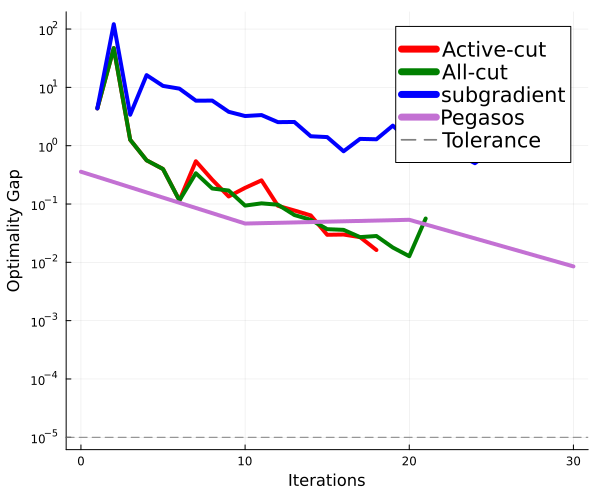

In [24]:
p = plot(size = (600,500))
for manage_bundle in manage_bundle_values
    # plot!(dic_gaps[manage_bundle], label = "", color = color_dic[manage_bundle],linewidth=4)
    plot!(dic_gaps[manage_bundle], label = dic_names_method[manage_bundle], color = color_dic[manage_bundle],linewidth=4)
end


plot!([s.objective for s in sol_subgradient.iteration_stats], label = "subgradient", linewidth = 4, color = "blue")
plot!(list_iter_index_pegasos, list_obj_value_gap_pegasos, label = "Pegasos", linewidth = 4)

hline!([eps_optimal], linestyle=:dash, label="Tolerance", color = "grey")
xlabel!("Iterations")
ylabel!("Optimality Gap")
plot!(legendfontsize=14)
# y_ticks = range(1e-4, stop=1e1, length=20)
# title!("Progress for different bundle management strategies")
plot!(yaxis=:log, yticks = [1e-5, 1e-4, 1e-3, 1e-2,1e-1, 1, 10, 100])
# ylims!(1e-5, 100)
# xlims!(-10, 1000)
savefig(p, "Optimality_gap.pdf") 
savefig(p, "proximal_bundle_method_main/outputs/Optimality_gap_by_iteration_"*name*"_"*string(coeff)*"_"*string(max_nb_samples)*"_rho_"*string(rho)*".pdf") 
plot!()

# Objective Gap vs time

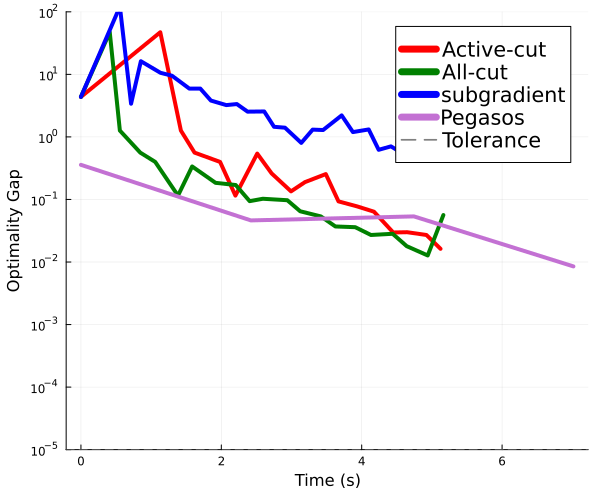

In [25]:
p = plot(size = (600,500))
for manage_bundle in manage_bundle_values
    # plot!(dic_gaps[manage_bundle], label = "", color = color_dic[manage_bundle],linewidth=4)
    plot!(dic_times[manage_bundle],dic_gaps[manage_bundle], label = dic_names_method[manage_bundle], color = color_dic[manage_bundle],linewidth=4)
end
plot!([s.time - sol_subgradient.iteration_stats[1].time for s in sol_subgradient.iteration_stats], ([s.objective for s in sol_subgradient.iteration_stats]), label = "subgradient", linewidth = 4, color = "blue")
plot!(list_times_pegasos, list_obj_value_gap_pegasos, label = "Pegasos", linewidth = 4)

hline!([eps_optimal], linestyle=:dash, label="Tolerance", color = "grey")
xlabel!("Time (s)")
ylabel!("Optimality Gap")
plot!(legendfontsize=14)
# y_ticks = range(1e-4, stop=1e1, length=20)
# title!("Progress for different bundle management strategies")
plot!(yaxis=:log, yticks = [1e-5, 1e-4, 1e-3, 1e-2,1e-1, 1, 10, 100])
ylims!(1e-5, 100)
# xlims!(-0.1, 500)
savefig(p, "proximal_bundle_method_main/outputs/Optimality_gap_by_time_"*name*"_"*string(coeff)*"_"*string(max_nb_samples)*"_rho_"*string(rho)*".pdf") 
plot!()

## Bundle size

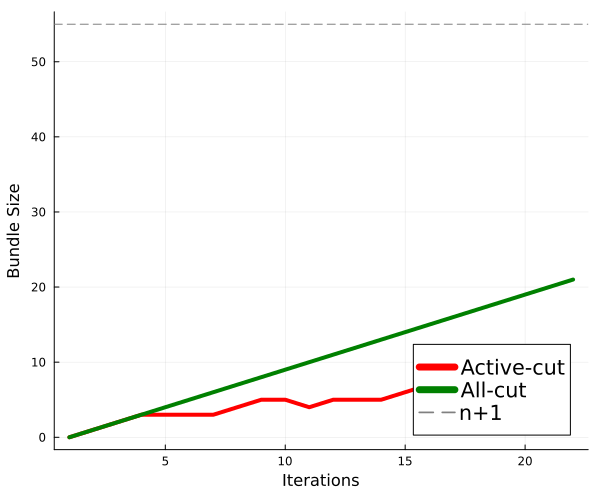

In [26]:
p = plot(size = (600,500))
for manage_bundle in manage_bundle_values
    plot!(dic_bundle_size[manage_bundle], label=dic_names_method[manage_bundle], color = color_dic[manage_bundle],linewidth=4)
end
hline!([size(Xp)[2]], linestyle=:dash, label="n+1", color = "grey")
xlabel!("Iterations")
ylabel!("Bundle Size")
plot!(legendfontsize=14)
# title!("Bundle Size for Different Bundle management strategies")
savefig(p, "proximal_bundle_method_main/outputs/Bundle_size_"*name*"_"*string(coeff)*"_"*string(max_nb_samples)*"_rho_"*string(rho)*".pdf")  
plot!()

## Output utils

In [27]:
function make_dic_runtime(dic_runtimes_bundle, dic_has_timeout_bundle, list_times_pegasos,has_timeout_pegasos, sol_subgradient)
    to_return_runtimes = Dict()
    for manage_bundle in keys(dic_times)
        if dic_has_timeout_bundle[manage_bundle]
            to_return_runtimes[manage_bundle] = Inf
        else
            to_return_runtimes[manage_bundle] = dic_runtimes_bundle[manage_bundle]
        end
    end
    if has_timeout_pegasos
        to_return_runtimes["Pegasos"] = Inf
    else
        to_return_runtimes["Pegasos"] = list_times_pegasos[end]
    end
    if (sol_subgradient.termination_reason == TERMINATION_REASON_OPTIMAL)
        to_return_runtimes["Subgradient"] = sol_subgradient.iteration_stats[end].time - sol_subgradient.iteration_stats[1].time
    else
        to_return_runtimes["Subgradient"] = Inf
    end
    return to_return_runtimes
end

dic_runtimes = make_dic_runtime(dic_runtimes_bundle, dic_has_timeout_bundle, list_times_pegasos,has_timeout_pegasos, sol_subgradient)
dic_runtimes

Dict{Any, Any} with 4 entries:
  Keep_all      => Inf
  Keep_active   => Inf
  "Pegasos"     => Inf
  "Subgradient" => Inf

# Single Run

In [28]:
# plot(dic_gaps)
# master_model.obj_dict
# optimize!(master_model)
# dual_dict_cut = Dict(key => dual(value) for (key, value) in dict_cut)
# histogram([dual(value) for (key, value) in dict_cut])

In [29]:
manage_bundle = Keep_active
# manage_bundle = Keep_all

# dict_cut,master_model, list_number_null_steps, number_serious_steps, bundle_size,runtime, list_obj_value_gap, times = solve_PBA(x_init,rho,epsilon,delta, manage_bundle, goal_obj);

Keep_active::Manage_bundle = 1

In [30]:
using LIBSVM

# Classification C-SVM
@time model = svmtrain(transpose(Xp),y, kernel = Kernel.Linear, cost = 1/coeff, tolerance = eps_optimal, verbose = false);
# model = fit!(SVC(), Xp, y)